In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from pathlib import Path

sys.path.append(os.path.abspath('..'))

# importar funções úteis do módulo de preprocessing
from src.preprocessing import *
from src.feature_engineering import *
from src.train import *
from src.utils import *
from src.evaluate import *

In [2]:
#Parâmetros globais
TARGET_COL = "ALTO_INDE"

NUMERIC_COLS = [
    "IAA", "IEG", "IPS", "IDA", "IPP", "IPV", "IAN",
    "DEFASAGEM", "NOTA_PORT", "NOTA_MAT", "NOTA_ING",
    "ANO_INGRESSO", "QTDE_AVAL"
]

CATEGORICAL_COLS = [
    "FASE", "TURMA"
]

In [3]:
# Carregar o arquivo Excel
file_path = r'C:\Users\erick\Documents\FIAP\TC\FASE5_DATATHON\Base_pede.xlsx'

# Carregar os dados de cada ano
df_2022 = pd.read_excel(file_path, sheet_name='PEDE2022')
df_2023 = pd.read_excel(file_path, sheet_name='PEDE2023')
df_2024 = pd.read_excel(file_path, sheet_name='PEDE2024')

# Padronizar colunas
df22 = padronizar_colunas(df_2022, column_mapping, year=2022, return_summary=False)
df23 = padronizar_colunas(df_2023, column_mapping, year=2023, return_summary=False)
df24 = padronizar_colunas(df_2024, column_mapping, year=2024, return_summary=False)

# Concatenar dataframes
df_concat = pd.concat([df22, df23, df24], ignore_index=True)

# Aplicar correção de idade e enforcer de schema
df_fix_idade = fix_idade(df_concat)
df_schema, schema_errors = enforce_schema(df_fix_idade, schema= EXPECTED_SCHEMA)

#Tratamento de missings
df_pede, missing_summary = handle_missing_values(
    df_schema,
    numeric_cols=NUMERIC_COLS,
    categorical_cols=CATEGORICAL_COLS,
    add_missing_flags=True
)

In [ ]:
#Exibição do dataframe para sanity-check
df_pede[df_pede["ANO_BASE"] == 2024].head()

,RA,FASE,TURMA,NOME,IDADE_ALUNO,ANO_INGRESSO,INSTITUICAO_ENSINO_ALUNO,PEDRA,INDE,CG,...,IPS_MISSING,IDA_MISSING,IPP_MISSING,IPV_MISSING,NOTA_PORT_MISSING,NOTA_MAT_MISSING,NOTA_ING_MISSING,QTDE_AVAL_MISSING,CF_MISSING,CT_MISSING
1874,RA-1275,ALFA,ALFA A - G0/G1,Aluno-1275,8,2024,Pública,Ametista,7.611367,NaN,...,0,0,0,0,0,0,0,0,1,1
1875,RA-1276,ALFA,ALFA A - G0/G1,Aluno-1276,8,2024,Pública,Topázio,8.002867,NaN,...,0,0,0,0,0,0,0,0,1,1
1876,RA-1277,ALFA,ALFA A - G0/G1,Aluno-1277,8,2024,Pública,Ametista,7.952200,NaN,...,0,0,0,0,0,0,0,0,1,1
1877,RA-868,ALFA,ALFA A - G0/G1,Aluno-868,8,2023,Pública,Ametista,7.156367,NaN,...,0,0,0,0,0,0,0,0,1,1
1878,RA-1278,ALFA,ALFA A - G0/G1,Aluno-1278,9,2024,Pública,Quartzo,5.444200,NaN,...,0,0,0,0,0,0,0,0,1,1


In [ ]:
#Garante que as transformações de feature engineering estão funcionando corretamente
df_fe = (
    df_pede
    .pipe(bin_idade)
    .pipe(encode_pedra)
    .pipe(create_basic_features)
)

assert TARGET_COL in df_fe.columns
assert "ANO_BASE" in df_fe.columns

In [6]:
# Cria DF do modelo
df_model = df_fe.copy()

#Divisão do modelo em treino e teste
model, X_train, X_test, y_train, y_test = train_model(
    df=df_fe,
    numeric_features=NUMERIC_COLS,
    categorical_features=CATEGORICAL_COLS,
    target_col=TARGET_COL,
    test_year=2024
)

,label,precision,recall,f1-score,support
0,0,0.867589,1.000000,0.929101,439.000000
1,1,1.000000,0.906555,0.950988,717.000000
2,accuracy,0.942042,0.942042,0.942042,0.942042
3,macro avg,0.933794,0.953278,0.940044,1156.000000
4,weighted avg,0.949716,0.942042,0.942676,1156.000000


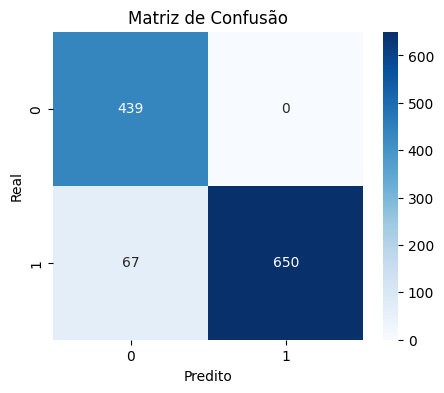

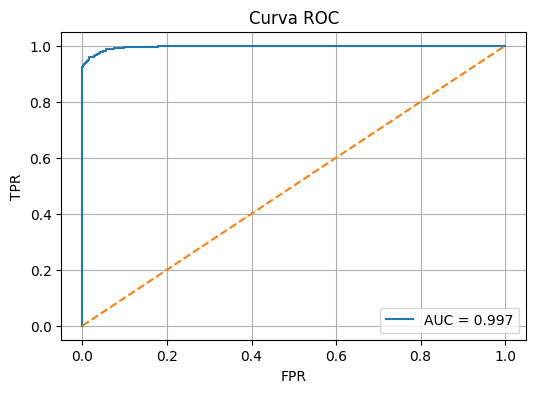

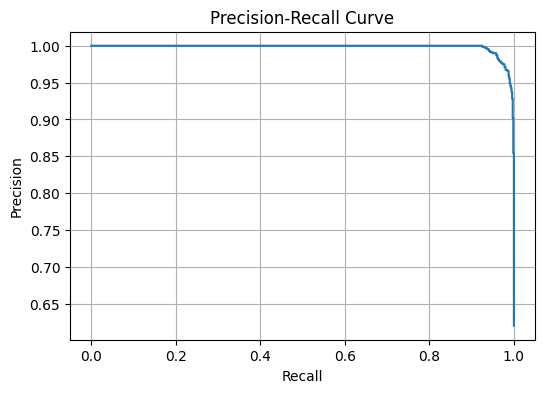

In [ ]:
#Métricas do modelo campeão
metrics_df, report_df, metrics_dict = evaluate_model(
    model,
    X_test,
    y_test,
    plot= True
)

metrics_df
report_df

In [ ]:
results_df = compare_models(
    df=df_model,
    numeric_features=NUMERIC_COLS,
    categorical_features=CATEGORICAL_COLS,
    target_col=TARGET_COL,
    test_year=2024
)

results_df

results_long = results_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1_score", "roc_auc"],
    var_name="metric",
    value_name="value"
)

c:\Users\erick\Documents\FIAP\TC\FASE5_DATATHON\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:33:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,accuracy,precision,recall,f1_score,roc_auc,model
0,0.942042,1.000000,0.906555,0.950988,0.996960,logistic
1,0.946367,0.986627,0.926081,0.955396,0.991686,random_forest
2,0.948962,0.982405,0.934449,0.957827,0.991041,xgboost


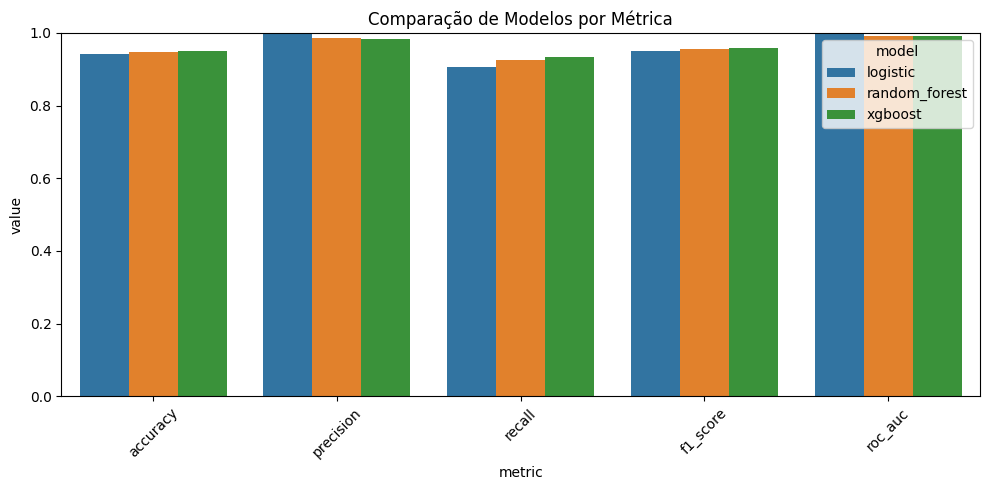

In [ ]:
#Gráfico de comparação dos modelos por métrica
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_long,
    x="metric",
    y="value",
    hue="model"
)

plt.ylim(0, 1)
plt.title("Comparação de Modelos por Métrica")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Cria o diretório de artefatos
ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

#Salva o modelo campeão
save_model(model, ARTIFACTS_DIR / "model_v1.joblib")

#Salva os datasets para monitoramento
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

train_df.to_parquet(ARTIFACTS_DIR / "train_data.parquet")
test_df.to_parquet(ARTIFACTS_DIR / "test_data.parquet")